* school - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)
* sex - student's sex (binary: 'F' - female or 'M' - male)
* age - student's age (numeric: from 15 to 22)
* address - student's home address type (binary: 'U' - urban or 'R' - rural)
* famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)
* Pstatus - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)
* Medu - mother's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
* Fedu - father's education (numeric: 0 - none, 1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education)
* Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
* Fjob - father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')
* reason - reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')
* guardian - student's guardian (nominal: 'mother', 'father' or 'other')
* traveltime - home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
* studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
* failures - number of past class failures (numeric: n if 1<=n<3, else 4)
* schoolsup - extra educational support (binary: yes or no)
* famsup - family educational support (binary: yes or no)
* paid - extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)
* activities - extra-curricular activities (binary: yes or no)
* nursery - attended nursery school (binary: yes or no)
* higher - wants to take higher education (binary: yes or no)
* internet - Internet access at home (binary: yes or no)
* romantic - with a romantic relationship (binary: yes or no)
* famrel - quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
* freetime - free time after school (numeric: from 1 - very low to 5 - very high)
* goout - going out with friends (numeric: from 1 - very low to 5 - very high)
* Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
* Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
* health - current health status (numeric: from 1 - very bad to 5 - very good)
* absences - number of school absences (numeric: from 0 to 93)


* G1 - first period grade (numeric: from 0 to 20)
* G2 - second period grade (numeric: from 0 to 20)
* G3 - final grade (numeric: from 0 to 20, output target)

## Erzeuge einen DataFrame aus `student-math.csv`

In [13]:
import pandas as pd

df = pd.read_csv('student-math.csv')

## Ermittle nach Geschlechtern gruppiert den durchschnittlichen Alkoholkonsum

In [14]:
df.groupby('sex')['Walc'].mean()

sex
F    1.956731
M    2.663102
Name: Walc, dtype: float64

## Ermittle jene 3 Features, welche am meisten mit `G3` korrelieren, abgesehen von `G1` und `G2`


In [15]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [col for col in numeric_cols if col not in ['G1', 'G2', 'G3']]
correlations = df[numeric_cols].corrwith(df['G3']).abs().nlargest(3)
correlations

failures    0.360415
Medu        0.217147
age         0.161579
dtype: float64

## Ermittle jene 3 Features, welche am meisten mit `Walc` korrelieren

In [16]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [col for col in numeric_cols if col != 'Walc']
correlations = df[numeric_cols].corrwith(df['Walc']).abs().nlargest(3)
correlations

Dalc         0.647544
goout        0.420386
studytime    0.253785
dtype: float64

## Ermittle die Absenzzahl jenes Schülers mit den meisten Absenzen, der trotzdem >= 10 G3 hat

In [17]:
df[df['G3'] >= 10]['absences'].max()

54

## Ermittle, ob die Schüler mit mehr als 18 Punkten eher aus dem ruralen oder aus dem urbanen Raum kommen

In [18]:
df[df['G3'] > 18]['address'].value_counts()

address
U    5
R    1
Name: count, dtype: int64

## Versuche, folgende Behauptung zu widerlegen:
"Dass die Eltern unter einem Dach leben ist sehr wichtig für eine **herausragende** Mathematiknote, immerhin leben doppelt so viele dieser Schüler mit **beiden** Eltern zusammen"

In [19]:
# outstanding G3 >= 15
outstanding = df[df['G3'] >= 15]
pstatus_counts = outstanding['Pstatus'].value_counts()
print("Pstatus counts for outstanding students:")
print(pstatus_counts)
print(f"Ratio T/A: {pstatus_counts['T'] / pstatus_counts['A']:.2f}")
print("The claim is disproven if ratio != 2.0")

Pstatus counts for outstanding students:
Pstatus
T    64
A     9
Name: count, dtype: int64
Ratio T/A: 7.11
The claim is disproven if ratio != 2.0


## Erzeuge folgende Graphik, welche die Punkte nach Adresse darstellt
<img align="left"
src="https://drive.google.com/uc?export=view&id=10Bciig5JKaGiFHeLtGSXjxJOE88jknDU">

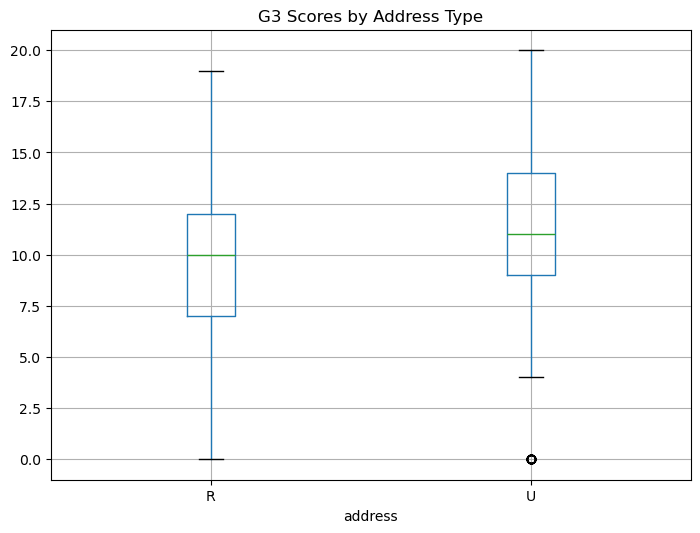

In [20]:
import matplotlib.pyplot as plt

df.boxplot(column='G3', by='address', figsize=(8,6))
plt.title('G3 Scores by Address Type')
plt.suptitle('')
plt.show()

## Ermittle die durchschnittliche Punktzahl aller Schüler, bei denen Mutter und Vater derselben Berufsgruppe angehören, gruppiert nach Berufsgruppe

In [21]:
same_job = df[df['Mjob'] == df['Fjob']]
same_job.groupby('Mjob')['G3'].mean()

Mjob
at_home     12.285714
health      13.500000
other        9.798077
services    10.767442
teacher     13.083333
Name: G3, dtype: float64

## Ersetze fehlende Werte durch den **Median** der jeweiligen `address`

In [22]:
print("Missing values before:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = df.groupby('address')[col].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
school         0
sex            0
age            0
address        0
famsize        0
Pstatus        0
Medu           0
Fedu           0
Mjob           0
Fjob           0
reason         0
guardian       0
traveltime    36
studytime      0
failures       0
schoolsup      0
famsup         0
paid           0
activities     0
nursery        0
higher         0
internet       0
romantic       0
famrel         0
freetime       0
goout          0
Dalc           0
Walc           0
health         0
absences       0
G1             0
G2             0
G3             0
dtype: int64

Missing values after:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel      